In [289]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import warnings
import seaborn as sns

In [3]:
df = pd.read_csv("house_price.csv")

In [5]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [11]:
duplicate_value = df.duplicated().sum()
print(f"Number of duplicated rows:{duplicate_value}")

Number of duplicated rows:529


In [13]:
df.drop_duplicates(inplace=True)
duplicate_value = df.duplicated().sum()
print(f"Number of duplicated rows:{duplicate_value}")

Number of duplicated rows:0


In [15]:
def unique_values(df):
    for i in df.columns:
        print(i,":",df[i].nunique())
unique_values(df)

area_type : 4
availability : 81
location : 1305
size : 31
society : 2688
total_sqft : 2117
bath : 19
balcony : 4
price : 1994


In [17]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5328
total_sqft         0
bath              73
balcony          605
price              0
dtype: int64

In [19]:
df.drop(columns=['society'], axis=1, inplace=True)

In [21]:
df.dropna(subset=['location','size','bath','balcony'],inplace=True)

In [23]:
def extract_rooms(value):
    try:
        return int(value.split(' ')[0])
    except:
        return np.nan

df['size_num'] = df['size'].apply(extract_rooms)

df.dropna(subset=['size'], inplace=True)

df.drop(columns=['size'], inplace=True)


In [25]:
df

,area_type,availability,location,total_sqft,bath,balcony,price,size_num
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2
...,...,...,...,...,...,...,...,...
13312,Super built-up Area,Ready To Move,Bellandur,1262,2.0,2.0,47.00,2
13314,Super built-up Area,Ready To Move,Green Glen Layout,1715,3.0,3.0,112.00,3
13315,Built-up Area,Ready To Move,Whitefield,3453,4.0,0.0,231.00,5
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00,2


In [27]:
def categorize_availability(value):
    if "Ready To Move" in value:
        return "Ready To Move"
    else:
        return "Under Construction"

df['availability'] = df['availability'].apply(categorize_availability)


In [29]:
df['availability'].unique()

array(['Under Construction', 'Ready To Move'], dtype=object)

In [31]:
def convert_sqft_to_num(value):
    try:
        
        if '-' in value:
            sqft_range = value.split('-')
            return (float(sqft_range[0]) + float(sqft_range[1])) / 2
        
        return float(value)
    except:
        return np.nan 
        
warnings.simplefilter('ignore', category=FutureWarning)

df['total_sqft_num'] = df['total_sqft'].apply(convert_sqft_to_num)
df['total_sqft_num'].fillna(df['total_sqft_num'].median(),inplace=True)

df.drop(columns=['total_sqft'], inplace=True)

In [ ]:
# df['bath'].fillna(df['bath'].median(), inplace=True)
# df['balcony'].fillna(df['balcony'].median(), inplace=True)
# warnings.filterwarnings('ignore', category=FutureWarning)

In [33]:
df = df[df['price'] < df['price'].quantile(0.99)]  # Remove top 1% of prices
df = df[df['total_sqft_num'] < df['total_sqft_num'].quantile(0.99)]

In [35]:
df['price'] = np.round(df['price']).astype(int)

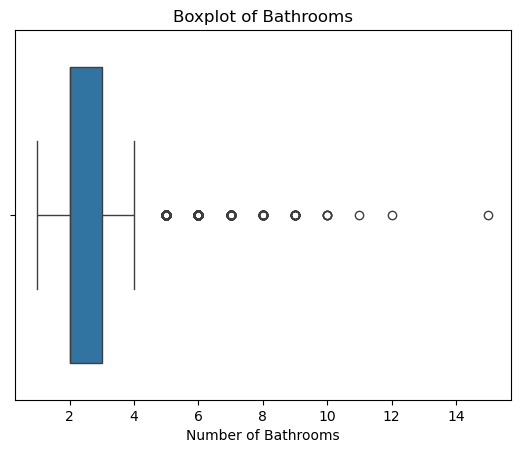

In [37]:
sns.boxplot(x=df['bath'])
plt.title('Boxplot of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.show()

In [39]:
value_counts = df['bath'].value_counts()
value_counts

bath
2.0     6463
3.0     3008
4.0      999
1.0      755
5.0      362
6.0      215
7.0       71
8.0       37
9.0       21
10.0       4
11.0       1
12.0       1
15.0       1
Name: count, dtype: int64

In [41]:
# Function to identify outliers using IQR
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Identify outliers in 'bath' 
outliers_bath = find_outliers(df, 'bath')

outliers_bath

,area_type,availability,location,bath,balcony,price,size_num,total_sqft_num
1,Plot Area,Ready To Move,Chikka Tirupathi,5.0,3.0,120,4,2600.0
11,Plot Area,Ready To Move,Whitefield,5.0,3.0,295,4,2785.0
22,Plot Area,Ready To Move,Thanisandra,5.0,2.0,380,4,2800.0
64,Built-up Area,Ready To Move,Bommanahalli,8.0,0.0,140,8,3000.0
68,Plot Area,Ready To Move,Devarachikkanahalli,7.0,0.0,85,8,1350.0
...,...,...,...,...,...,...,...,...
13268,Super built-up Area,Under Construction,EPIP Zone,5.0,2.0,221,4,3360.0
13281,Plot Area,Ready To Move,Margondanahalli,5.0,1.0,125,5,1375.0
13293,Super built-up Area,Ready To Move,Sarjapur Road,5.0,1.0,195,4,2425.0
13300,Plot Area,Ready To Move,Hosakerehalli,6.0,2.0,145,5,1500.0


In [43]:
len(outliers_bath)

713

In [45]:
df= df[~df.index.isin(outliers_bath.index)]

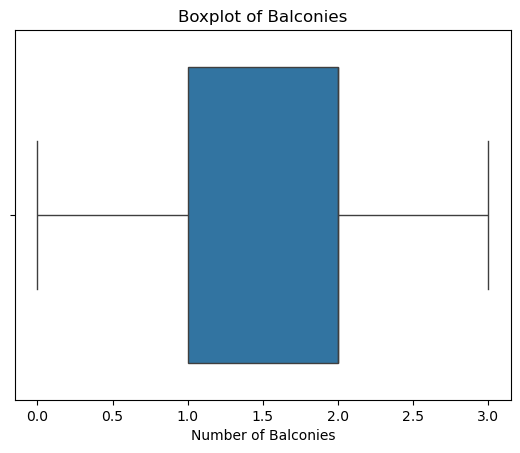

In [47]:
sns.boxplot(x=df['balcony'])
plt.title('Boxplot of Balconies')
plt.xlabel('Number of Balconies')
plt.show()

In [49]:
df.shape

(11225, 8)

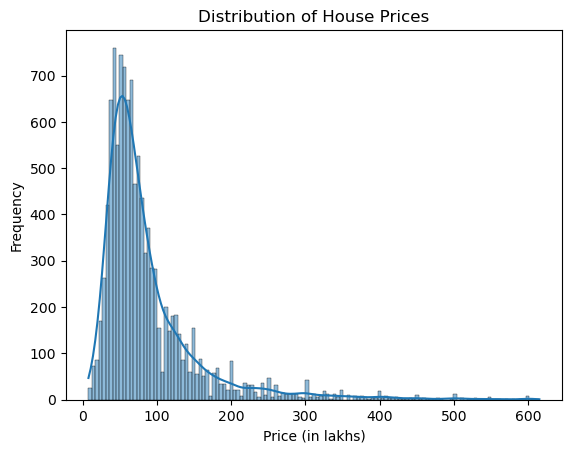

In [51]:
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price (in lakhs)')
plt.ylabel('Frequency')
plt.show()

In [53]:
df.isna().sum()

area_type         0
availability      0
location          0
bath              0
balcony           0
price             0
size_num          0
total_sqft_num    0
dtype: int64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11225 entries, 0 to 13317
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       11225 non-null  object 
 1   availability    11225 non-null  object 
 2   location        11225 non-null  object 
 3   bath            11225 non-null  float64
 4   balcony         11225 non-null  float64
 5   price           11225 non-null  int32  
 6   size_num        11225 non-null  int64  
 7   total_sqft_num  11225 non-null  float64
dtypes: float64(3), int32(1), int64(1), object(3)
memory usage: 745.4+ KB


In [57]:
df.describe()

,bath,balcony,price,size_num,total_sqft_num
count,11225.000000,11225.000000,11225.000000,11225.000000,11225.000000
mean,2.378708,1.564633,88.751002,2.537461,1381.206927
std,0.740171,0.802335,71.179741,0.801954,544.487303
min,1.000000,0.000000,8.000000,1.000000,11.000000
25%,2.000000,1.000000,48.000000,2.000000,1085.000000
50%,2.000000,2.000000,67.000000,2.000000,1250.000000
75%,3.000000,2.000000,100.000000,3.000000,1575.000000
max,4.000000,3.000000,615.000000,8.000000,4260.000000


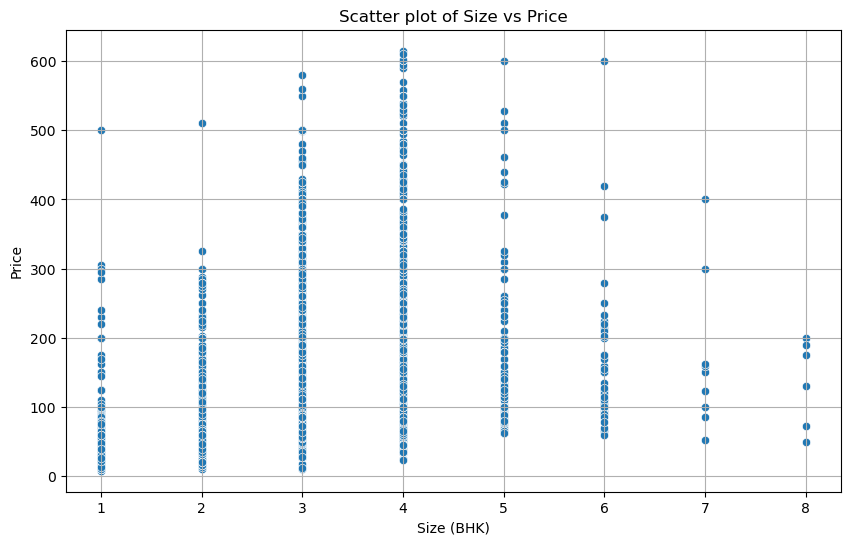

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='size_num', y='price', data=df)
plt.title('Scatter plot of Size vs Price')
plt.xlabel('Size (BHK)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

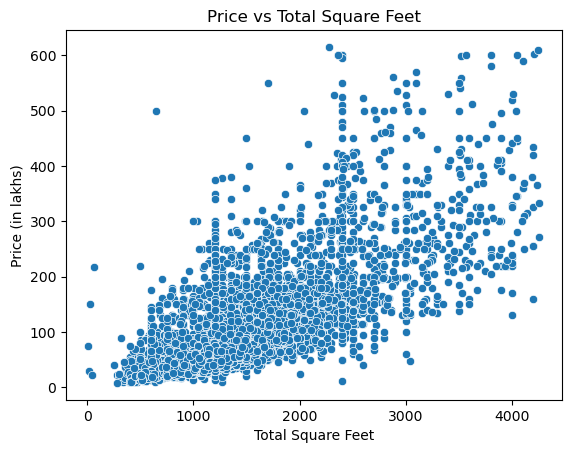

In [61]:
sns.scatterplot(x='total_sqft_num', y='price', data=df)
plt.title('Price vs Total Square Feet')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (in lakhs)')
plt.show()

In [63]:
df = pd.get_dummies(df, drop_first=True)

In [65]:
X = df.drop(columns=['price'])
y = df['price']

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
rg = RandomForestRegressor(random_state = 42)
rg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [73]:
# predicting the model
y_pred = rg.predict(X_test)
# r2 score
r2 = r2_score(y_test, y_pred )
print(f'R-squared: {r2}')

R-squared: 0.738114511558483


In [75]:
xg = XGBRegressor(random_state=42)
xg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [77]:
# predicting the model
y_pred = xg.predict(X_test)
# r2 score
r2 = r2_score(y_test, y_pred )
print(f'R-squared: {r2}')

R-squared: 0.773177444934845


In [244]:
rgd = Ridge(random_state = 42)
rgd.fit(X_train, y_train)

Ridge(random_state=42)

In [248]:
# predicting the model
y_pred_rgd = rgd.predict(X_test)
# r2 score
r2 = r2_score(y_test, y_pred_rgd )
print(f'R-squared: {r2}')

R-squared: 0.7457133972874215


In [277]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
y_pred_gbr = model.predict(X_test)

In [279]:
# r2 score
r2 = r2_score(y_test, y_pred_gbr )
print(f'R-squared: {r2}')

R-squared: 0.7317793345869124


In [310]:
# Step 5: Retrieve the best parameters and model
best_params = random_search.best_params_
best_model = random_search.best_estimator_
print("Best Parameters:", best_params)

Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_leaf_nodes': 100, 'max_features': None, 'max_depth': 10, 'criterion': 'squared_error'}


In [321]:
param_distributions = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2']
}

In [329]:
gbr = GradientBoostingRegressor(random_state=42)

In [331]:
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [333]:
# Fit the model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 10],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [300, 500, 700],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [349]:
# Best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.2}


In [351]:
# Evaluate on the test set
best_model = random_search.best_estimator_
y_pred_gbr = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_gbr)
print("Mean Squared Error on Test Set:", mse)

Mean Squared Error on Test Set: 1060.8024097986613


In [353]:
# r2 score
r2 = r2_score(y_test, y_pred_gbr )
print(f'R-squared: {r2}')

R-squared: 0.7932059481413463


In [175]:
param_grid = {
    'n_estimators': [500,700,900],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [0.5, 1, 2],
    'bootstrap': [True, False]
}

In [160]:
model = RandomForestRegressor(random_state=42)

In [162]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

In [164]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [0.5, 1, 2],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [300, 500, 700]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [167]:
# Print the best parameters and the corresponding score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)

Best Parameters: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best Score: 1431.8273987296204


In [169]:
# Evaluate the best model on the test set
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", test_rmse)

Test RMSE: 34.569175354123644


In [171]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 1195.0278846641497


In [173]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:",r2)

R2 Score: 0.7670398784249752


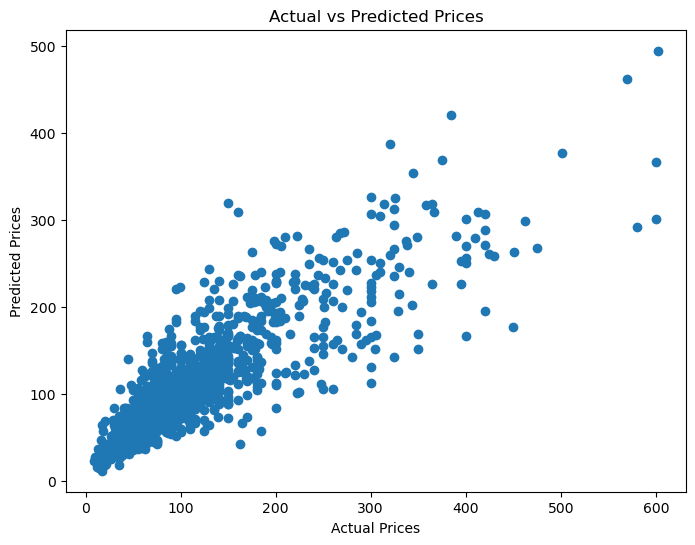

In [139]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [99]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [5, 7, 10],
    'subsample': [0.6, 1.0, 2.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [0.2, 0.5, 1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 1, 2],
    'reg_lambda': [0.5, 1, 1.5, 3]
}

In [101]:
xgb = XGBRegressor(random_state=42)

In [103]:
# Set up the randomized search with 50 iterations and 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)


In [105]:
# Fit the random search model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [0.5, 1, 3, 5, 7],
                                        'n_estimators': [100, 200, 500, 700],
                                        'reg_alpha': [0, 0.1, 1, 2],
                                        'reg_lambda': [0.5, 1, 1.5, 2, 5],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [108]:
# Print the best parameters and the corresponding score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 0.5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Best Score: 1474.1741596118663


In [110]:
y_pred_xgb = random_search.predict(X_test)
print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost R2 Score: 0.7759484052658081


In [112]:
mse = mean_squared_error(y_test, y_pred_xgb)
print("Mean Squared Error:",mse)

Mean Squared Error: 1149.3293267811796


In [114]:
# Evaluate the best model on the test set
best_xgb = random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", test_rmse)

Test RMSE: 34.110757522583214


In [116]:
print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost R2 Score: 0.7759484052658081


In [228]:
# Define the parameter grid for Ridge Regression
param_grid = {
    'alpha': np.logspace(-4, 4, 50),  # Regularization strength
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'saga'],
    'max_iter': [1000, 5000, 10000] 
}


In [230]:
# Instantiate the Ridge Regressor
ridge = Ridge()

In [232]:
# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

In [234]:
# Fit the random search model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=Ridge(), n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-...
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
                                        'max_iter': [1000, 5000, 10000],
                                        'solver': ['auto', 'svd', 'cholesky',
                                                   'lsqr', 'sparse_cg',
                                                   'saga']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [236]:
# Print the best parameters and the corresponding score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)

Best Parameters: {'solver': 'saga', 'max_iter': 5000, 'alpha': 339.3221771895323}
Best Score: 1669.7534557683045


In [219]:
# Evaluate the best model on the test set
best_ridge = random_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print("Test RMSE:", test_rmse)

XGBoost R2 Score: -1.3445422976576484e+28


In [238]:
y_pred_ridge = random_search.predict(X_test)
print("XGBoost R2 Score:", r2_score(y_test, y_pred_ridge))

XGBoost R2 Score: 0.7475106773973985


In [242]:
mse = mean_squared_error(y_test, y_pred_ridge)
print("Mean Squared Error:",mse)

Mean Squared Error: 1295.2078624018848
